# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Ugnius
* Username: uzukas
* Student number: S6292259
* Group (AS1, etc.): AS6

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

/tmp/ipykernel_1527396/641988867.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  rot.append(np.sqrt(G * m / R[i]))


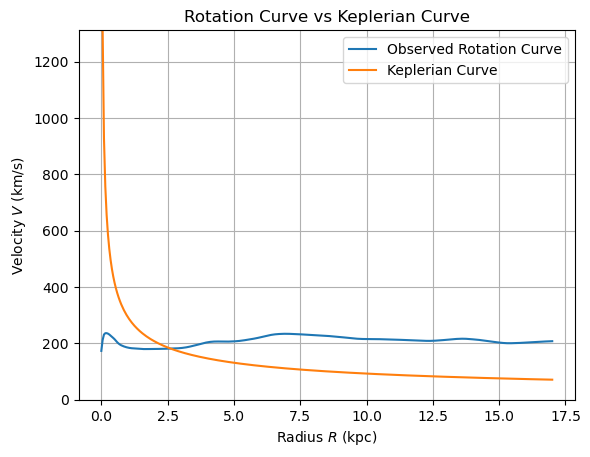

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("rotcur.dat")

G = 4.302e-6
m = 2e10
R = data[:,0]
V = data[:,1]
rot = []
for i in range(len(R)):
    rot.append(np.sqrt(G * m / R[i])) 
rot[0] = rot[1] # after calculating the list, i realized it goes to infinity because of /0, so I replaced it with the second largest number
np.savetxt("keplerian_curve.txt", rot)

V_kep = np.loadtxt("keplerian_curve.txt")


plt.plot(R, V, label=r"Observed Rotation Curve")
plt.plot(R, V_kep, label=r"Keplerian Curve")
plt.ylim(0, max(V_kep))
plt.xlabel(r"Radius $R$ (kpc)")
plt.ylabel(r"Velocity $V$ (km/s)")
plt.legend()
plt.grid(True)
plt.title("Rotation Curve vs Keplerian Curve")
plt.show()

# the expected rotational speeds assume all mass is concentrated in the center, so it should be very fast there while slowing down significantly on the
# edges. In reality we see a mostly uniform distribution, due to dark matter distrubuted along the galaxy keeping it more uniform in mass

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

1.0206711766414367 -0.02792537826478153


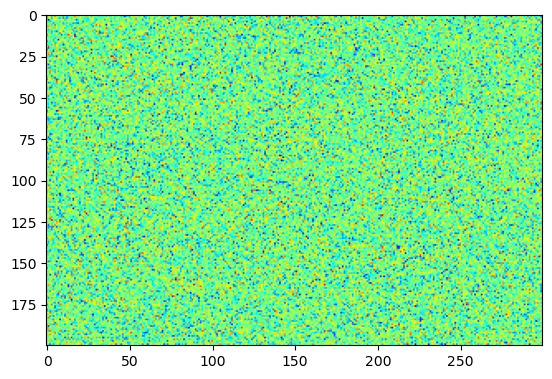

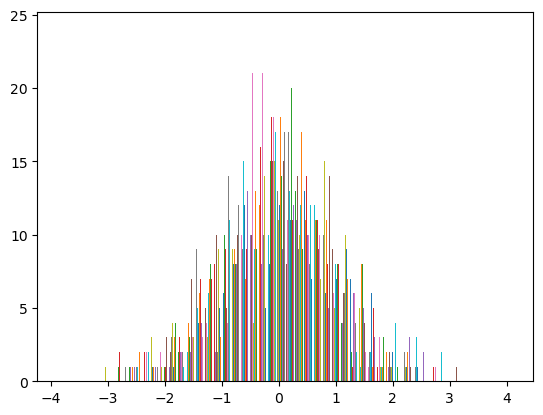

In [4]:
import numpy as np
import matplotlib.pyplot as plt

normal = np.random.normal(0, 1, (200, 300))

patch = normal[20:50, 80:110]

patch_std = np.std(patch)
patch_mean = np.mean(patch)

print(patch_std, patch_mean) # yeah, the values are very close to the ones i input

plt.imshow(normal, cmap="jet")
plt.figure()
plt.hist(normal, bins=50)
plt.show() # from the histogram we do get a normal distrubution again, though it it less peaky in the middle

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Area: 18.84955592153876


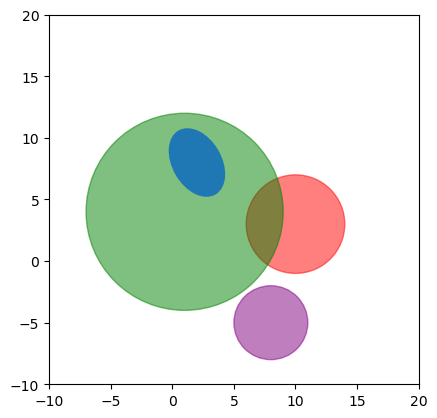

Center: (2, 8), semi-major:3.0, semi-minor:2.0, angle:30


In [1]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        # We use the (sort of) astronomical angle where 'angle' defines)
        # the position angle of the major axis of a ring projected onto the sky
        # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
        # the north direction on the sky and the major axis of the receding half of the
        # galaxy (Rots 1975, astron, astrophys 45, 43).
        # Here we assume (!) north is in the positive Y direction.
        # If not, you need to correct the angle for the rotation of the image.
        # Parameter 'position_angle' enters in degrees
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
    def area(self):
        return np.pi*self.height/2*self.width/2
    def __str__(self):
        return f"Center: {self.center}, semi-major:{self.height/2}, semi-minor:{self.width/2}, angle:{self.angle}"

class circle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args):
        super().__init__(xc, yc, radius, radius, 0, **args) # class for circle which uses ellipse class, and just makes both axis one radius

ellipse = AstroEllipse(2, 8, 3, 2, 30)
circle1 = circle(10, 3, 4, alpha=0.5, color="red")
circle2 = circle(1, 4, 8, alpha=0.5, color="green")
circle3 = circle(8, -5, 3, alpha=0.5, color="purple")
fig, ax = plt.subplots()
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)
ax.add_patch(ellipse)
ax.set_aspect("equal")
ax.set_xlim(-10, 20)
ax.set_ylim(-10, 20) # calling all shapes and setting up plot

print("Area:", ellipse.area())
plt.show()

print(ellipse.__str__())

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

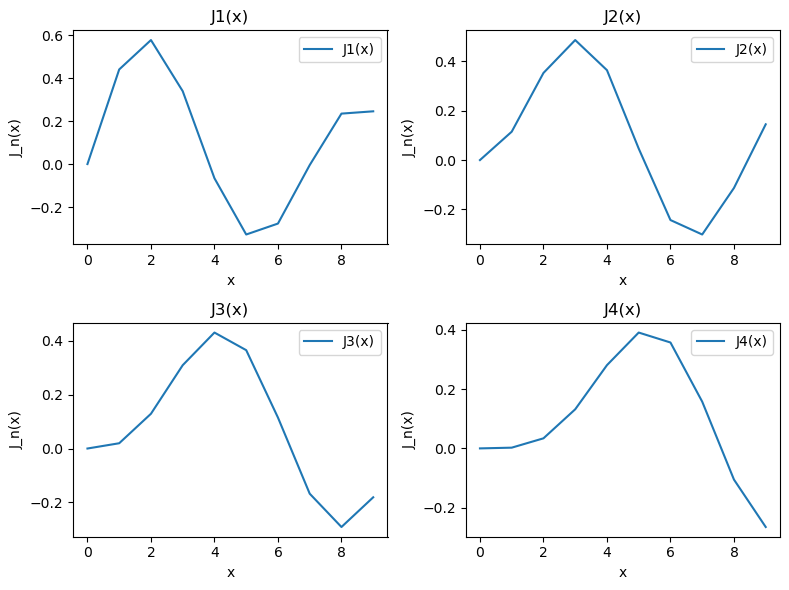

In [70]:
from scipy.special import jv
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0, 10)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0,0].plot(x, jv(1, x), label='J1(x)')
axes[0,1].plot(x, jv(2, x), label='J2(x)')
axes[1,0].plot(x, jv(3, x), label='J3(x)')
axes[1,1].plot(x, jv(4, x), label='J4(x)') # creating all plots using subplots

axes[0,0].set_title('J1(x)')
axes[0,1].set_title('J2(x)')
axes[1,0].set_title('J3(x)')
axes[1,1].set_title('J4(x)') 

for ax in axes.flat:
    ax.legend()
    ax.set_xlabel('x')
    ax.set_ylabel('J_n(x)') # naming axises compactly

plt.tight_layout()
plt.savefig("things.png") # saving image
plt.show()

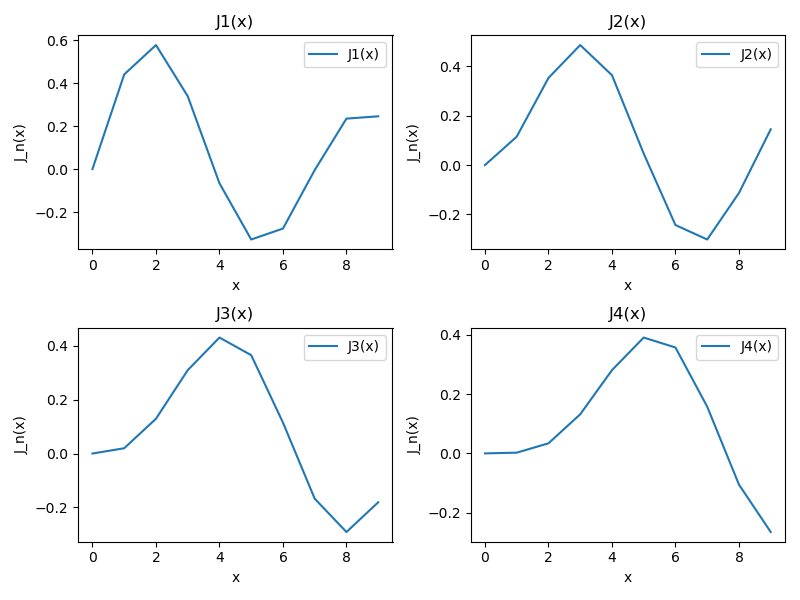

In [8]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

(0.0, 80.0)

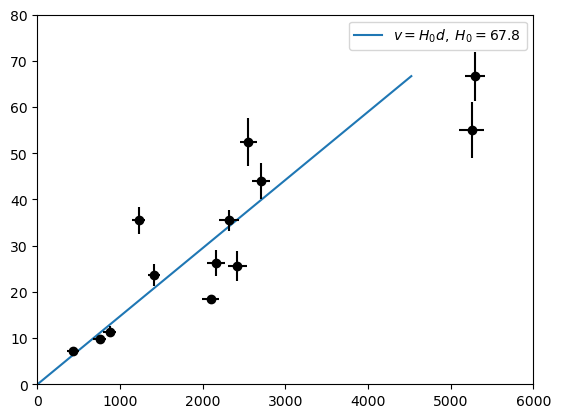

In [108]:
import matplotlib.pyplot as plt
import numpy as np

H = 67.8

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
]

d = np.array(data[0::4])
v = data[1::4]
d_err = data[2::4]
v_err = data[3::4]

d_h = np.linspace(0, np.max(d), 200) # I assume as long as the slope is the same the d does not matter as long as I have it's range
                                     # so I brute forced the origin like this

v_H = H*d_h

fig, axes = plt.subplots()

axes.plot(v_H, d_h, label=rf"$v = H_0 d, \; H_0={H}$")
axes.errorbar(v, d, xerr=v_err, yerr=d_err, fmt="o", color="black") # plotting all the data after making the subplots

axes.legend()
axes.set_xlim(0, 6000)
axes.set_ylim(0, 80) # for readability of the graph

In [9]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [10]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
